# Bitcoin Market Sentiment Analysis

### Submitted by: Dhanya Chilakalapudi

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load Datasets

In [ ]:
trades = pd.read_csv("/content/historical_data.csv")
sentiment = pd.read_csv("/content/fear_greed_index.csv")

/tmp/ipykernel_17499/2815354804.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("/content/historical_data.csv")


## Explore the Datasets

In [ ]:
trades[['Timestamp IST', 'Timestamp']].head(10)

,Timestamp IST,Timestamp
0,02-12-2024 22:50,1.730000e+12
1,02-12-2024 22:50,1.730000e+12
2,02-12-2024 22:50,1.730000e+12
3,02-12-2024 22:50,1.730000e+12
4,02-12-2024 22:50,1.730000e+12
5,02-12-2024 22:50,1.730000e+12
6,02-12-2024 22:50,1.730000e+12
7,02-12-2024 22:50,1.730000e+12
8,02-12-2024 22:50,1.730000e+12
9,02-12-2024 22:50,1.730000e+12


## Data Preprocessing

In [ ]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['Date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

In [ ]:
trades[['Timestamp IST', 'Date']].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


## Merge the Datasets

In [ ]:
df = pd.merge(
    trades,
    sentiment,
    on='Date',
    how='left'
)

In [ ]:
df[['Date', 'classification']].head(10)

,Date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed
5,2024-12-02,Extreme Greed
6,2024-12-02,Extreme Greed
7,2024-12-02,Extreme Greed
8,2024-12-02,Extreme Greed
9,2024-12-02,Extreme Greed


In [ ]:
df['classification'].value_counts()

,count
classification,
Fear,36200
Greed,35139
Neutral,24578
Extreme Greed,21504
Extreme Fear,8403


In [ ]:
df.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

,Closed PnL
classification,
Extreme Greed,85.831404
Fear,73.783558
Extreme Fear,69.691964
Neutral,48.951258
Greed,35.398986


In [ ]:
df.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

,Closed PnL
classification,
Fear,2.670965e+06
Extreme Greed,1.845719e+06
Greed,1.243885e+06
Neutral,1.203124e+06
Extreme Fear,5.856216e+05


In [ ]:
wins = df[df['Closed PnL'] > 0]
wins['classification'].value_counts()

,count
classification,
Fear,15835
Greed,12593
Neutral,10081
Extreme Greed,9703
Extreme Fear,2996


In [ ]:
losses = df[df['Closed PnL'] < 0]
losses['classification'].value_counts()


,count
classification,
Greed,4297
Fear,1453
Neutral,1173
Extreme Greed,909
Extreme Fear,546


In [ ]:
df.groupby('classification')['Fee'].mean()


,Fee
classification,
Extreme Fear,0.847594
Extreme Greed,0.977274
Fear,1.610103
Greed,1.516504
Neutral,1.198280


## Data Visualization

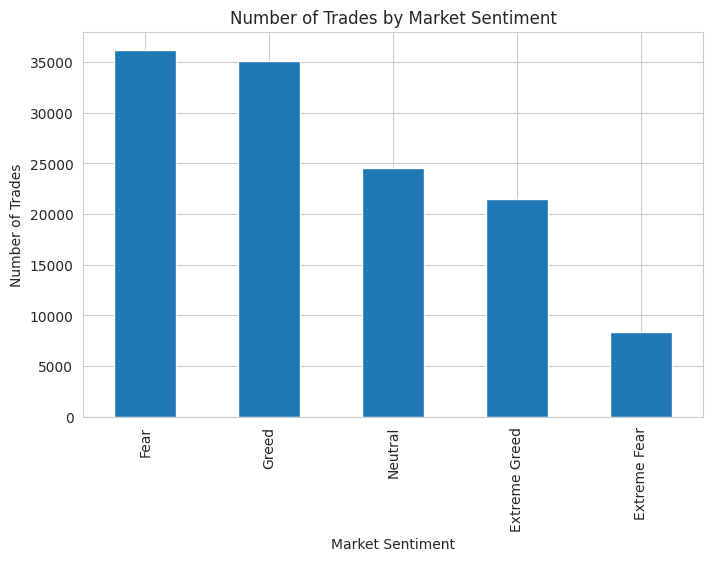

In [ ]:
trade_count = df['classification'].value_counts()

trade_count.plot(kind='bar', figsize=(8,5))
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

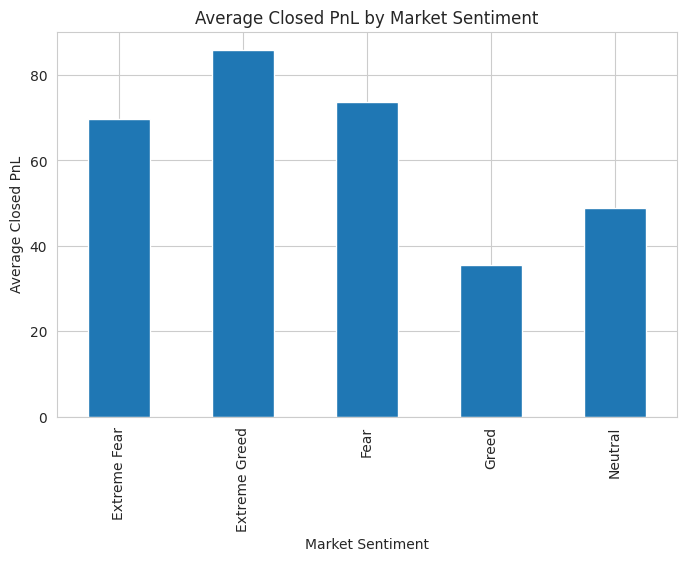

In [ ]:
avg_profit = df.groupby('classification')['Closed PnL'].mean()

avg_profit.plot(kind='bar', figsize=(8,5))
plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()


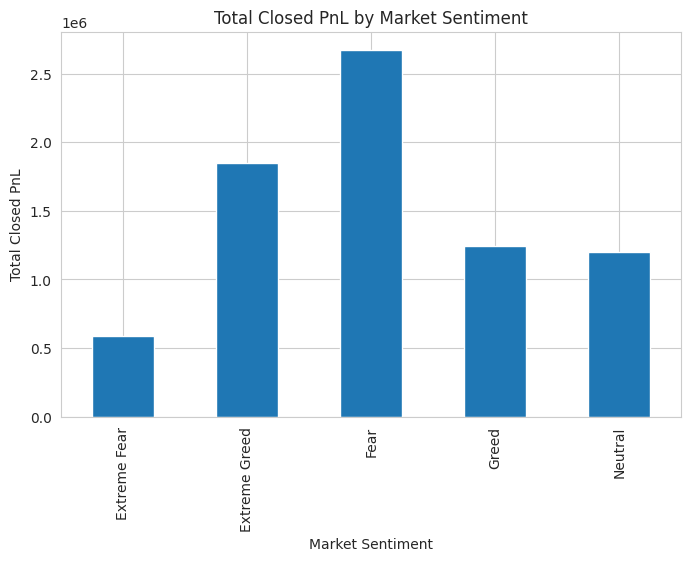

In [ ]:
total_profit = df.groupby('classification')['Closed PnL'].sum()

total_profit.plot(kind='bar', figsize=(8,5))
plt.title("Total Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.show()

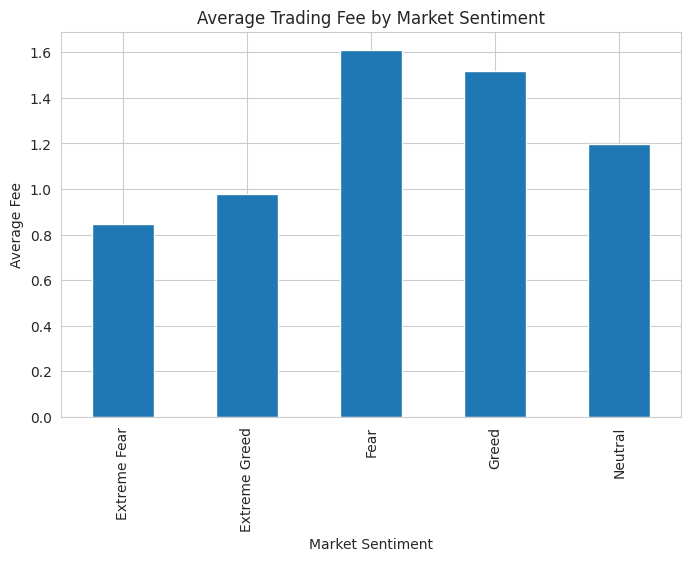

In [ ]:
avg_fee = df.groupby('classification')['Fee'].mean()

avg_fee.plot(kind='bar', figsize=(8,5))
plt.title("Average Trading Fee by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Fee")
plt.show()

## Top 10 Profitable Traders

In [ ]:
top_traders = df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.087312e+05
Name: Closed PnL, dtype: float64


## Key Insights

- Fear sentiment had the highest number of trades.
- Extreme Greed generated the highest average profit per trade.
- Fear produced the highest total realized profit.
- Greed had the lowest average profit.
- Winning trades were highest during Fear.
- Losing trades were highest during Greed.
- Trading fees were highest during Fear.

## Conclusion

The analysis shows that market sentiment has a significant impact on trader performance. Fear periods generated the highest overall profit due to higher trading activity, while Extreme Greed provided the highest average profit per trade. These findings suggest that market sentiment can be a valuable indicator for developing better trading strategies.